In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import random
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D



DATASET PATH

In [23]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\asd\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [24]:
import os

base_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

print(os.listdir(train_dir))

['NORMAL', 'PNEUMONIA']


DATA AUGMENTATION

In [25]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
     width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


IMAGE QUALITY FUNCTION

In [26]:
def image_quality_weight(img):
    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    contrast = gray.std()
    
    weight = (sharpness/(sharpness+100)) + (contrast/(contrast+50))
    return weight

FEATURE EXTRACTOR

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

feature_extractor = Model(inputs=base_model.input, outputs=x)

print("Feature extractor ready")

Feature extractor ready


FEATURE EXTRACTION

In [28]:
def extract_features_with_quality(generator, model):
    features, labels = [], []
    
    generator.reset()
    for i in range(len(generator)):
        imgs, lbls = generator[i]
        feats = model.predict(imgs, verbose=0)
        
        weighted_feats = []
        for j in range(len(imgs)):
            w = image_quality_weight(imgs[j])
            weighted_feats.append(feats[j] * w)
        
        features.append(np.array(weighted_feats))
        labels.append(lbls)
    
    return np.vstack(features), np.hstack(labels)

X_train, y_train = extract_features_with_quality(train_data, feature_extractor)
X_test,  y_test  = extract_features_with_quality(test_data, feature_extractor)

print("Feature shapes:", X_train.shape, X_test.shape)

Feature shapes: (4695, 1280) (624, 1280)


PCA

In [29]:
from sklearn.decomposition import PCA

# Reduce feature size (important for SVM)
pca = PCA(n_components=150)

X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

print("After PCA:", X_train.shape)

After PCA: (4695, 150)


COMPUTE CLASS WEIGHTS

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = 'balanced'

print("Class Weights:", class_weights)

Class Weights: balanced


TRAIN SVM

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        class_weight=class_weights
    ))
])

svm_model.fit(X_train, y_train)

print("SVM trained successfully")

SVM trained successfully


THRESHOLD TUNING

In [32]:
params = {
    'svm__C': [1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001]
}

grid = GridSearchCV(svm_model, params, cv=3, scoring='f1', verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

svm_model = grid.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .........................svm__C=1, svm__gamma=scale; total time=   4.1s
[CV] END .........................svm__C=1, svm__gamma=scale; total time=   4.9s
[CV] END .........................svm__C=1, svm__gamma=scale; total time=   4.3s
[CV] END ..........................svm__C=1, svm__gamma=0.01; total time=   6.4s
[CV] END ..........................svm__C=1, svm__gamma=0.01; total time=   6.1s
[CV] END ..........................svm__C=1, svm__gamma=0.01; total time=   7.1s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   3.6s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   4.8s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   3.9s
[CV] END ........................svm__C=10, svm__gamma=scale; total time=   5.8s
[CV] END ........................svm__C=10, svm__gamma=scale; total time=   5.0s
[CV] END ........................svm__C=10, svm__

In [33]:
from sklearn.metrics import *
from sklearn.metrics import roc_curve

# Predict probabilities

probs = svm_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)

# Specificity = 1 - FPR
specificity = (1 - fpr)+tpr

# choose threshold where specificity is high (e.g. > 0.9)
idx = np.argmax(specificity)
best_threshold = thresholds[idx]

print("Best threshold:", best_threshold)


y_pred = (probs > best_threshold).astype(int)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC
auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", auc)
# Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

Best threshold: 0.8474565316228642
Accuracy : 0.8910256410256411
Precision: 0.93048128342246
Recall   : 0.8923076923076924
F1 Score : 0.9109947643979057

Confusion Matrix:
 [[208  26]
 [ 42 348]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86       234
         1.0       0.93      0.89      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.89      0.89       624
weighted avg       0.89      0.89      0.89       624

ROC-AUC: 0.951939513477975
Specificity: 0.8888888888888888


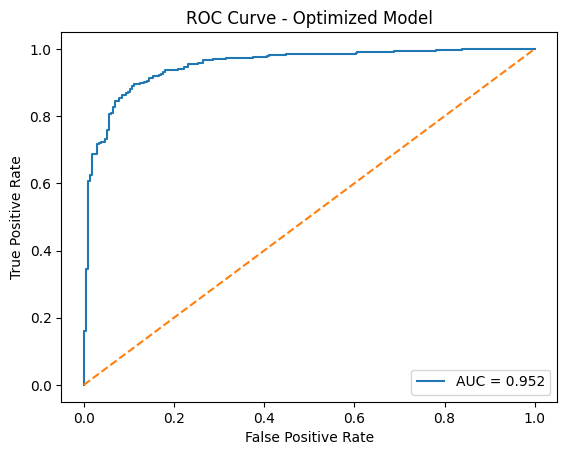

In [34]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Model")
plt.legend()
plt.show()

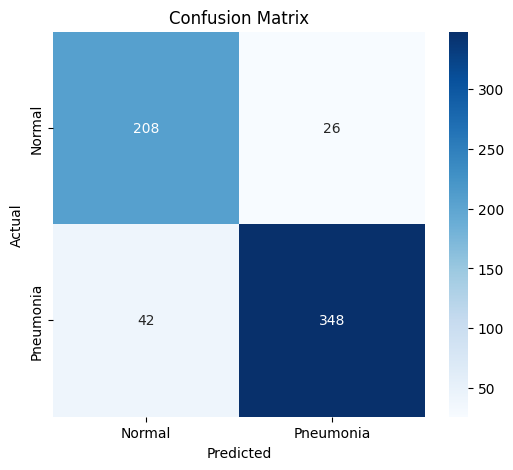

In [35]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


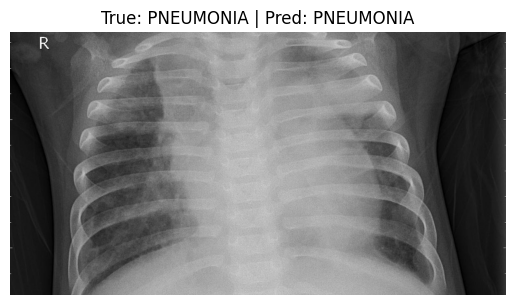

In [36]:
import random
import cv2

idx = random.randint(0, len(test_data.filenames)-1)

img_path = os.path.join(test_dir, test_data.filenames[idx])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, IMG_SIZE) / 255.0

feat = feature_extractor.predict(np.expand_dims(img_resized, axis=0))
w = image_quality_weight(img_resized)
feat = feat * w

# Apply PCA also
feat = pca.transform(feat)

pred = svm_model.predict(feat)[0]

true_label = test_data.classes[idx]

plt.imshow(img)
plt.title(f"True: {'PNEUMONIA' if true_label==1 else 'NORMAL'} | Pred: {'PNEUMONIA' if pred==1 else 'NORMAL'}")
plt.axis("off")
plt.show()

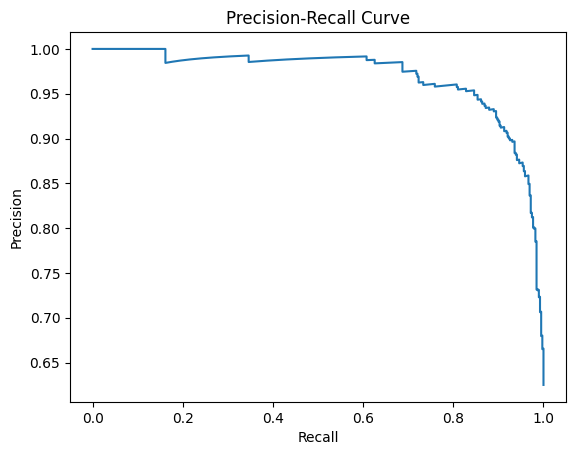

In [37]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs)

plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_datagen = ImageDataGenerator(rescale=1./255)

val_data = val_datagen.flow_from_directory(
    val_dir,                      # path to validation folder
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 16 images belonging to 2 classes.
